# Step 2b — Advanced State Competitiveness Indicators
**Objective:** Build on Step 2 with advanced competitiveness metrics — revealing not just what states trade and with whom, but how competitive they are structurally, how concentrated their product base is, and what their logistical profile looks like.

**Prerequisites:** Step 2 must have been run first. This notebook reuses `df_state` and other dataframes from that session, or re-queries them where needed.

This notebook covers:
1. Revealed Comparative Advantage (RCA) by State and SH2 Sector
2. Export Specialisation Index by State
3. Product Concentration Index by State (HHI at product level)
4. Export Frequency — Number of Shipments by State
5. Average Shipment Size by State (kg and USD per shipment)
6. Logistics Profile Summary — Bulk vs High-Frequency Exporters
7. Key Findings

## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv

dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data
MAX_YEAR = 2025

## Re-query state totals in case Step 2 session is not active
query_state_totals = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""
df_state = pd.read_sql(query_state_totals, engine)
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
print(f"State totals loaded: {len(df_state)} states")

Connected to database successfully
State totals loaded: 29 states


## 2b.1 — Revealed Comparative Advantage (RCA) by State and SH2 Sector
The RCA index measures whether a state exports a given sector more intensively than Brazil does nationally.

**Formula:** RCA = (State share in sector) / (National share in sector)

- RCA > 1 → the state has a comparative advantage in that sector
- RCA < 1 → the state is less specialised in that sector than the national average

Calculated at SH2 sector level for all states in MAX_YEAR.

### 2b.1.1 — Revealed Comparative Advantage (RCA) by Top 10 States and Top 10 SH2 Sector

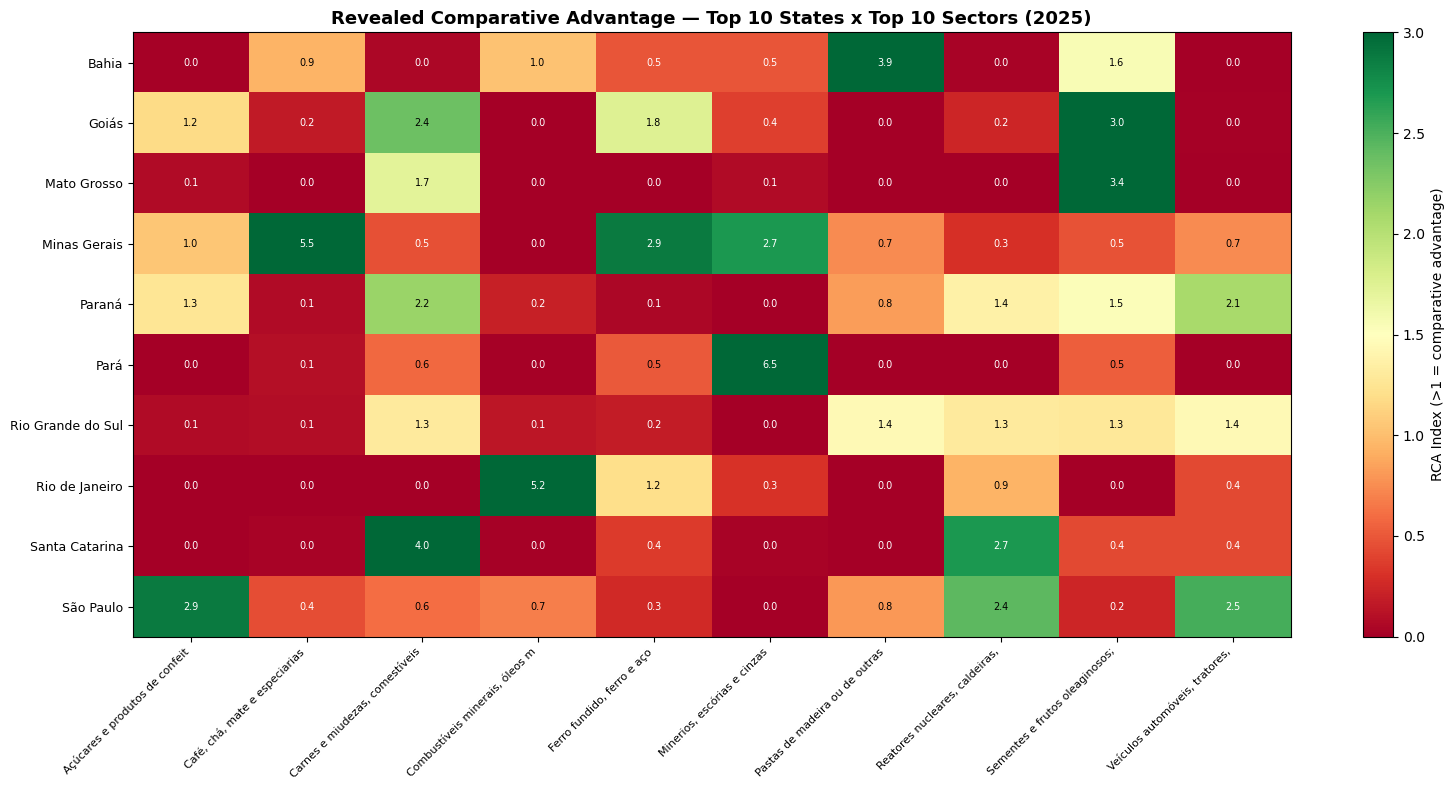


Top 5 sectors by RCA per state (2025) — sectors where RCA > 1 indicate comparative advantage

  São Paulo
    Aeronaves e aparelhos espaciais, e suas parte RCA=4.53  $4.54bn
    Estanho e suas obras                          RCA=4.44  $0.26bn
    Fibras sintéticas ou artificiais, descontínua RCA=4.21  $0.05bn
    Produtos para fotografia e cinematografia     RCA=4.10  $0.03bn
    Tapetes e outros revestimentos para pisos (pa RCA=4.04  $0.02bn

  Rio de Janeiro
    Combustíveis minerais, óleos minerais e produ RCA=5.18  $40.79bn
    Níquel e suas obras                           RCA=2.59  $0.02bn
    Embarcações e estruturas flutuantes           RCA=1.96  $0.02bn
    Obras de espartaria ou de cestaria            RCA=1.52  $0.00bn
    Borracha e suas obras                         RCA=1.27  $0.34bn

  Minas Gerais
    Zinco e suas obras                            RCA=7.37  $0.19bn
    Outros metais comuns; ceramais (cermets); obr RCA=7.01  $0.20bn
    Café, chá, mate e especiarias         

In [9]:
## Exports by state and SH2 sector
query_rca = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_rca_raw = pd.read_sql(query_rca, engine)

## State total exports
state_totals = df_rca_raw.groupby('uf')['exports_usd'].sum().rename('state_total')
df_rca_raw   = df_rca_raw.join(state_totals, on='uf')

## National total exports per sector
national_sector = df_rca_raw.groupby('sector')['exports_usd'].sum().rename('national_sector')
df_rca_raw      = df_rca_raw.join(national_sector, on='sector')

## National total exports
national_total = df_rca_raw['exports_usd'].sum()

## RCA = (state_sector / state_total) / (national_sector / national_total)
df_rca_raw['state_sector_share']    = df_rca_raw['exports_usd']    / df_rca_raw['state_total']
df_rca_raw['national_sector_share'] = df_rca_raw['national_sector'] / national_total
df_rca_raw['rca'] = (df_rca_raw['state_sector_share'] / df_rca_raw['national_sector_share']).round(3)

## Focus on top 10 exporting states and top 10 sectors by national value
top10_states  = df_state.head(10)['state'].tolist()
top10_sectors = (
    df_rca_raw.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)

df_rca_heat = df_rca_raw[
    df_rca_raw['state'].isin(top10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)

## Shorten sector labels for readability
df_rca_heat.columns = [str(c)[:30] for c in df_rca_heat.columns]

## Heatmap
fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat.columns)))
ax.set_xticklabels(df_rca_heat.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat.index)))
ax.set_yticklabels(df_rca_heat.index, fontsize=9)

## Annotate cells with RCA value
for i in range(len(df_rca_heat.index)):
    for j in range(len(df_rca_heat.columns)):
        val = df_rca_heat.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Top 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1_rca_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Print top 5 RCA sectors per state
print(f"\nTop 5 sectors by RCA per state ({MAX_YEAR}) — sectors where RCA > 1 indicate comparative advantage")
for state in top10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

### 2b.1.2 — Revealed Comparative Advantage (RCA) by Lowest 10 States and Top 10 SH2 Sector

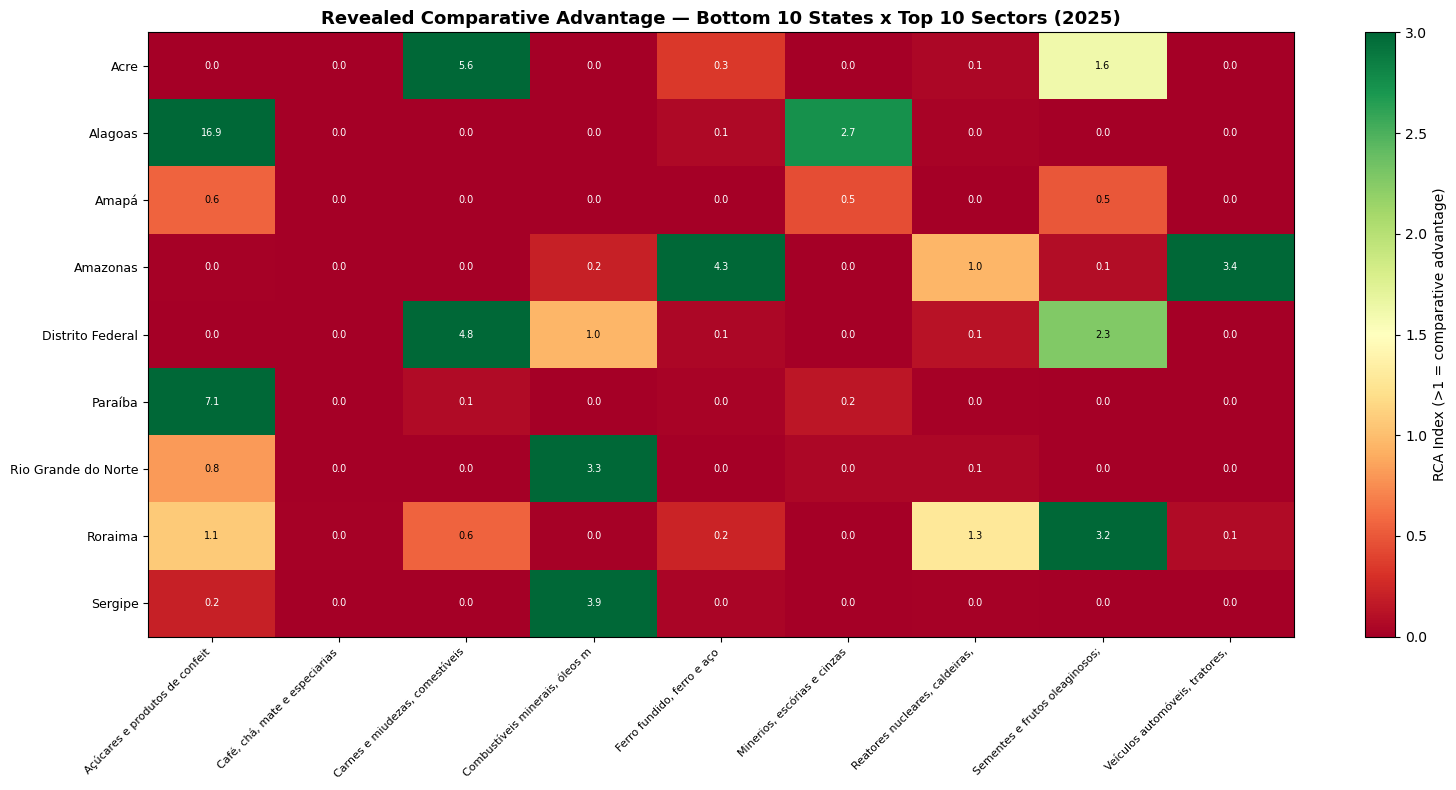


Top 5 sectors by RCA — Bottom 10 exporting states (2025)

  Rio Grande do Norte
    Frutas; cascas de frutos cítricos e de melões RCA=60.03  $0.27bn
    Peixes e crustáceos, moluscos e outros invert RCA=21.68  $0.03bn
    Sal; enxofre; terras e pedras; gesso, cal e c RCA=10.11  $0.03bn
    Outros produtos de origem animal, não especif RCA=5.77  $0.01bn
    Pérolas naturais ou cultivadas, pedras precio RCA=4.14  $0.10bn

  Amazonas
    Brinquedos, jogos, artigos para divertimento  RCA=43.01  $0.01bn
    Preparações alimentícias diversas             RCA=38.44  $0.21bn
    Ferramentas, artefatos de cutelaria e talhere RCA=24.32  $0.03bn
    Obras diversas                                RCA=20.86  $0.01bn
    Pérolas naturais ou cultivadas, pedras precio RCA=8.70  $0.17bn

  Alagoas
    Açúcares e produtos de confeitaria            RCA=16.91  $0.57bn
    Produtos cerâmicos                            RCA=3.10  $0.00bn
    Minerios, escórias e cinzas                   RCA=2.73  $0.23bn
    

In [10]:
## RCA heatmap for the 10 lowest exporting states
## Uses df_rca_raw already computed above — no additional query needed

bottom10_states = df_state.tail(10)['state'].tolist()

df_rca_heat_bottom = df_rca_raw[
    df_rca_raw['state'].isin(bottom10_states) &
    df_rca_raw['sector'].isin(top10_sectors)
].pivot(index='state', columns='sector', values='rca').fillna(0)

df_rca_heat_bottom.columns = [str(c)[:30] for c in df_rca_heat_bottom.columns]

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.imshow(df_rca_heat_bottom.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=3)
ax.set_xticks(range(len(df_rca_heat_bottom.columns)))
ax.set_xticklabels(df_rca_heat_bottom.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(df_rca_heat_bottom.index)))
ax.set_yticklabels(df_rca_heat_bottom.index, fontsize=9)

for i in range(len(df_rca_heat_bottom.index)):
    for j in range(len(df_rca_heat_bottom.columns)):
        val = df_rca_heat_bottom.values[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=7,
                color='black' if 0.5 < val < 2.5 else 'white')

plt.colorbar(im, ax=ax, label='RCA Index (>1 = comparative advantage)')
ax.set_title(f'Revealed Comparative Advantage — Bottom 10 States x Top 10 Sectors ({MAX_YEAR})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b1b_rca_heatmap_bottom10.png', dpi=150, bbox_inches='tight')
plt.show()

## Print top 5 RCA sectors per state for bottom 10
print(f"\nTop 5 sectors by RCA — Bottom 10 exporting states ({MAX_YEAR})")
for state in bottom10_states:
    subset = df_rca_raw[
        (df_rca_raw['state'] == state) & (df_rca_raw['rca'] > 1)
    ].nlargest(5, 'rca')[['sector', 'rca', 'exports_usd']]
    subset['exports_usd_bn'] = (subset['exports_usd'] / 1e9).round(2)
    print(f"\n  {state}")
    if subset.empty:
        print("    No sectors with RCA > 1")
    else:
        for _, row in subset.iterrows():
            print(f"    {str(row['sector'])[:45]:<45} RCA={row['rca']:.2f}  ${row['exports_usd_bn']:.2f}bn")

## 2b.2 — Export Specialisation Index by State
The Export Specialisation Index measures the degree to which a state's export basket is concentrated in a few sectors relative to the national average. A high index means the state exports a narrow range of products. A low index means its export mix mirrors Brazil's national mix.

**Formula:** ESI = sum of |state_sector_share - national_sector_share| for all sectors

Range: 0 (identical to national mix) to 2 (completely different from national mix).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_29680\1016213126.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())


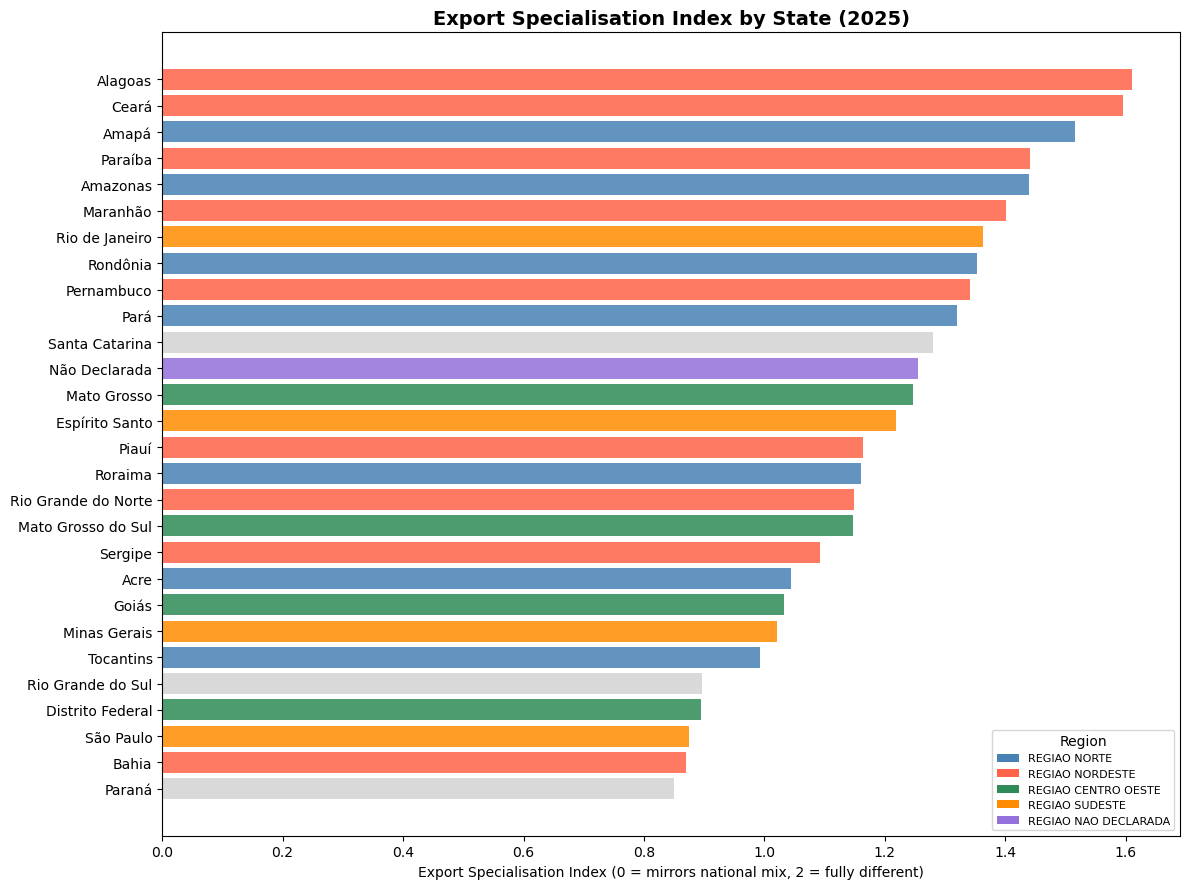


Export Specialisation Index by state (2025)
Higher ESI = more specialised / less diversified relative to national mix
              state               region  exports_usd_bn    esi
            Alagoas      REGIAO NORDESTE            0.82 1.6096
              Ceará      REGIAO NORDESTE            2.28 1.5946
              Amapá         REGIAO NORTE            0.14 1.5152
            Paraíba      REGIAO NORDESTE            0.18 1.4403
           Amazonas         REGIAO NORTE            0.94 1.4397
           Maranhão      REGIAO NORDESTE            5.02 1.4011
     Rio de Janeiro       REGIAO SUDESTE           48.98 1.3629
           Rondônia         REGIAO NORTE            3.09 1.3531
         Pernambuco      REGIAO NORDESTE            2.54 1.3415
               Pará         REGIAO NORTE           24.34 1.3199
     Santa Catarina           REGIAO SUL           12.20 1.2806
      Não Declarada REGIAO NAO DECLARADA            2.31 1.2551
        Mato Grosso  REGIAO CENTRO OESTE         

In [4]:
## Uses df_rca_raw from 2b.1
df_esi = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] - x['national_sector_share']).abs().sum())
    .reset_index()
    .rename(columns={0: 'esi'})
)
df_esi['esi'] = df_esi['esi'].round(4)
df_esi = df_esi.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')
df_esi_plot = df_esi.sort_values('esi', ascending=True)

## Colour by region
region_colors = {
    r: c for r, c in zip(
        df_esi['region'].dropna().unique(),
        ['steelblue', 'tomato', 'seagreen', 'darkorange', 'mediumpurple']
    )
}
bar_colors = df_esi_plot['region'].map(region_colors).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_esi_plot['state'], df_esi_plot['esi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Export Specialisation Index by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Export Specialisation Index (0 = mirrors national mix, 2 = fully different)')

## Region legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b2_esi.png', dpi=150)
plt.show()

print(f"\nExport Specialisation Index by state ({MAX_YEAR})")
print("Higher ESI = more specialised / less diversified relative to national mix")
print(df_esi[['state', 'region', 'exports_usd_bn', 'esi']]
      .sort_values('esi', ascending=False)
      .to_string(index=False))

## 2b.3 — Product Concentration Index by State (HHI at Product Level)
The HHI (Herfindahl-Hirschman Index) at the SH2 sector level measures how concentrated each state's export basket is. A high HHI means the state depends heavily on one or two sectors. A low HHI means exports are spread across many sectors.

**Formula:** HHI = sum of (sector_share)² for all sectors in a state

Range: close to 0 (very diversified) to 1 (single product monopoly).

C:\Users\e_koh\AppData\Local\Temp\ipykernel_29680\2259499169.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['state_sector_share'] ** 2).sum())


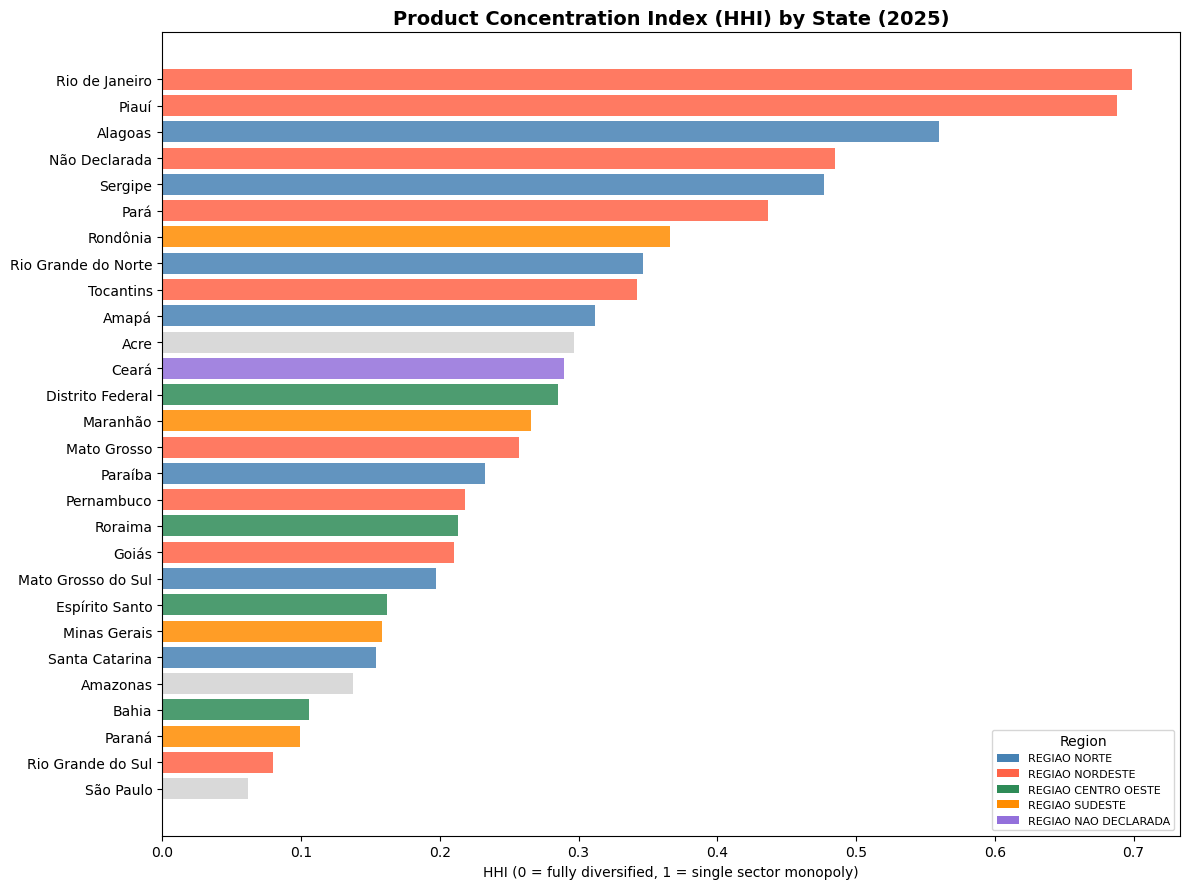


Product concentration HHI by state (2025)
Higher HHI = more concentrated in fewer sectors
              state               region  exports_usd_bn    hhi
     Rio de Janeiro       REGIAO SUDESTE           48.98 0.6985
              Piauí      REGIAO NORDESTE            1.20 0.6879
            Alagoas      REGIAO NORDESTE            0.82 0.5594
      Não Declarada REGIAO NAO DECLARADA            2.31 0.4849
            Sergipe      REGIAO NORDESTE            0.45 0.4771
               Pará         REGIAO NORTE           24.34 0.4365
           Rondônia         REGIAO NORTE            3.09 0.3658
Rio Grande do Norte      REGIAO NORDESTE            1.13 0.3462
          Tocantins         REGIAO NORTE            3.05 0.3418
              Amapá         REGIAO NORTE            0.14 0.3119
               Acre         REGIAO NORTE            0.10 0.2969
              Ceará      REGIAO NORDESTE            2.28 0.2894
   Distrito Federal  REGIAO CENTRO OESTE            0.32 0.2852
           Ma

In [5]:
## Uses df_rca_raw from 2b.1
df_hhi_prod = (
    df_rca_raw.groupby(['uf', 'state'])
    .apply(lambda x: (x['state_sector_share'] ** 2).sum())
    .reset_index()
    .rename(columns={0: 'hhi'})
)
df_hhi_prod['hhi'] = df_hhi_prod['hhi'].round(4)
df_hhi_prod = df_hhi_prod.merge(df_state[['uf', 'exports_usd_bn', 'region']], on='uf', how='left')

df_hhi_plot = df_hhi_prod.sort_values('hhi', ascending=True)
bar_colors = df_esi_plot['region'].map(region_colors).fillna('lightgray')

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color=bar_colors, alpha=0.85)
ax.set_title(f'Product Concentration Index (HHI) by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('HHI (0 = fully diversified, 1 = single sector monopoly)')
legend_elements = [Patch(facecolor=c, label=r) for r, c in region_colors.items()]
ax.legend(handles=legend_elements, fontsize=8, title='Region')
plt.tight_layout()
plt.savefig('output_2b3_hhi_product.png', dpi=150)
plt.show()

print(f"\nProduct concentration HHI by state ({MAX_YEAR})")
print("Higher HHI = more concentrated in fewer sectors")
print(df_hhi_prod[['state', 'region', 'exports_usd_bn', 'hhi']]
      .sort_values('hhi', ascending=False)
      .to_string(index=False))

## 2b.4 — Export Frequency: Number of Shipments by State
Counting the number of export transactions (rows) per state per year as a proxy for shipment frequency. High frequency states tend to be industrial exporters with diverse product lines. Low frequency states tend to be bulk commodity exporters with fewer but larger transactions.

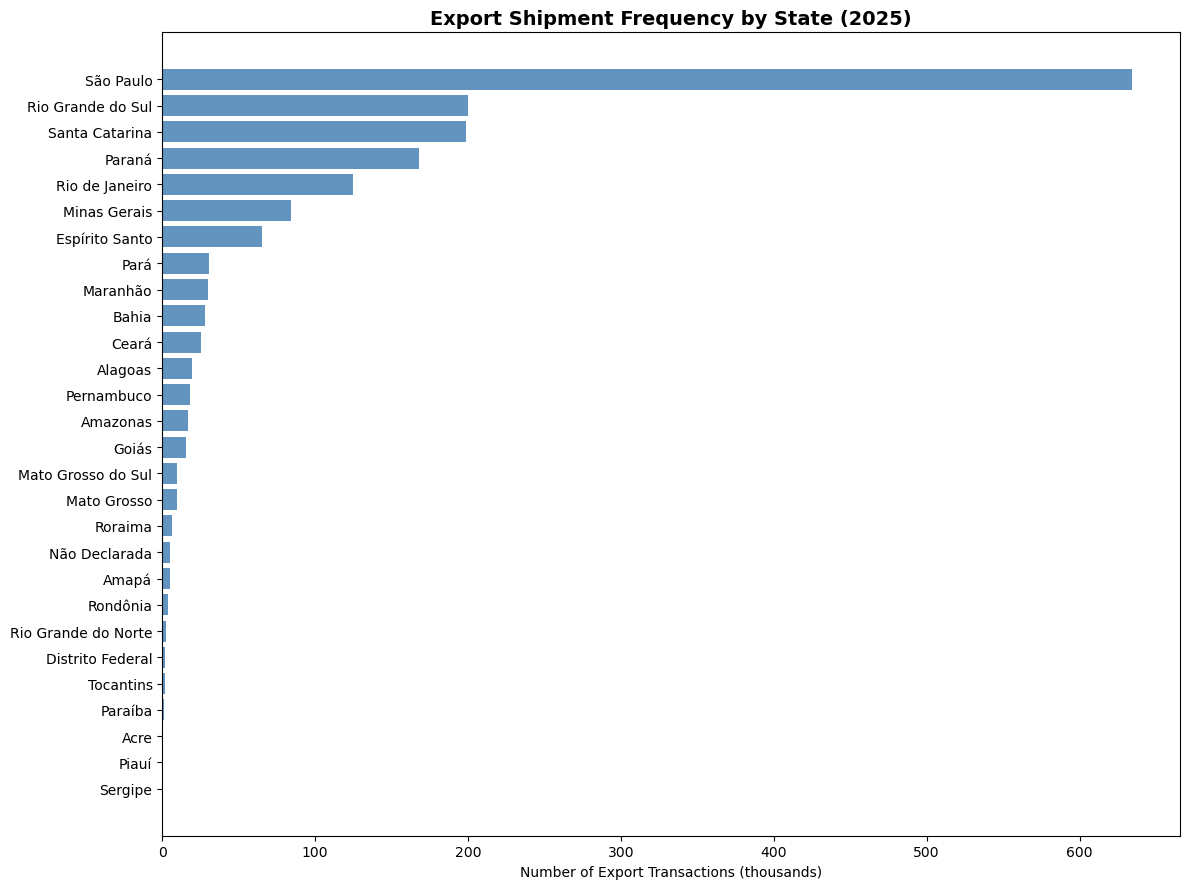


Export shipment frequency by state (2025)
              state  exports_usd_bn  shipment_count  shipment_count_k
          São Paulo           71.39          633996             634.0
  Rio Grande do Sul           21.53          200290             200.3
     Santa Catarina           12.20          198582             198.6
             Paraná           23.65          168230             168.2
     Rio de Janeiro           48.98          125063             125.1
       Minas Gerais           45.83           84438              84.4
     Espírito Santo           10.51           64958              65.0
               Pará           24.34           30292              30.3
           Maranhão            5.02           30183              30.2
              Bahia           11.63           27716              27.7
              Ceará            2.28           25439              25.4
            Alagoas            0.82           19543              19.5
         Pernambuco            2.54           1

In [6]:
query_freq = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           COUNT(*) AS shipment_count,
           SUM(e."VL_FOB") AS exports_usd,
           SUM(e."KG_LIQUIDO") AS total_kg,
           SUM(e."QT_ESTAT") AS total_units
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY shipment_count DESC
"""

df_freq = pd.read_sql(query_freq, engine)
df_freq['exports_usd_bn']    = (df_freq['exports_usd'] / 1e9).round(2)
df_freq['shipment_count_k']  = (df_freq['shipment_count'] / 1000).round(1)

df_freq_plot = df_freq.sort_values('shipment_count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_freq_plot['state'], df_freq_plot['shipment_count_k'],
        color='steelblue', alpha=0.85)
ax.set_title(f'Export Shipment Frequency by State ({MAX_YEAR})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Export Transactions (thousands)')
plt.tight_layout()
plt.savefig('output_2b4_shipment_frequency.png', dpi=150)
plt.show()

print(f"\nExport shipment frequency by state ({MAX_YEAR})")
print(df_freq[['state', 'exports_usd_bn', 'shipment_count', 'shipment_count_k']]
      .sort_values('shipment_count', ascending=False)
      .to_string(index=False))

## 2b.5 — Average Shipment Size by State (kg and USD per Transaction)
Average shipment size is calculated as total kg and total USD divided by the number of transactions. Large average shipments indicate bulk commodity exporters. Small average shipments indicate high-frequency industrial or processed goods exporters.

### 2b.5.1 — Average Shipment Size by State (Kg and USD per Transaction)

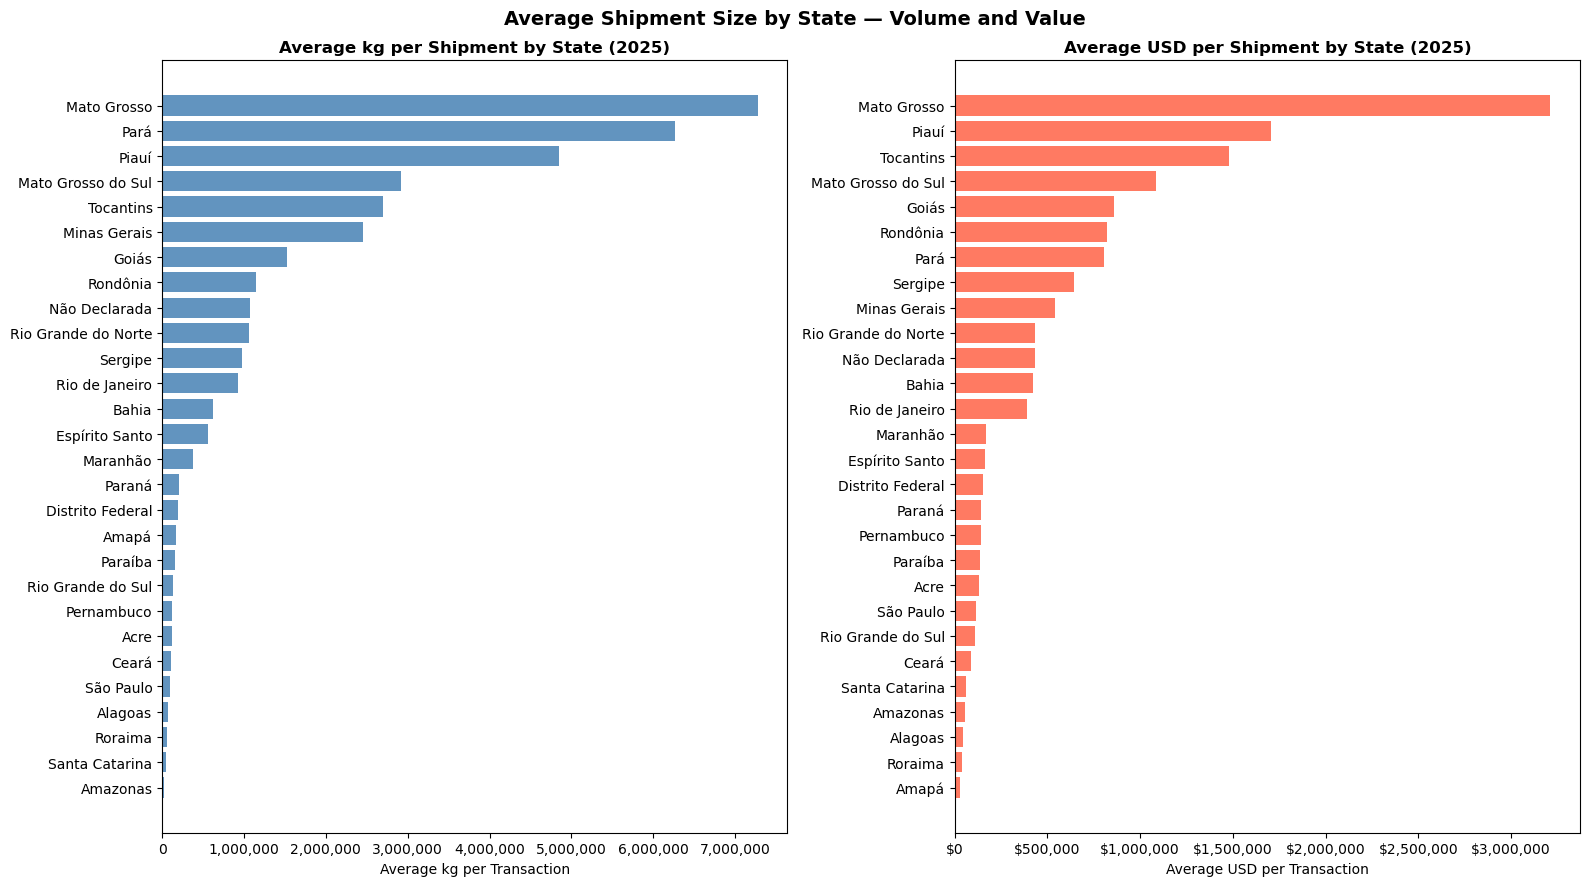


Average shipment size by state (2025)
              state  shipment_count  avg_kg_per_shipment  avg_usd_per_shipment
        Mato Grosso            9403            7276112.0             3210634.0
               Pará           30292            6262519.0              803390.0
              Piauí             704            4846119.0             1706456.0
 Mato Grosso do Sul            9926            2920785.0             1083455.0
          Tocantins            2064            2696422.0             1476915.0
       Minas Gerais           84438            2453172.0              542805.0
              Goiás           15684            1519562.0              858856.0
           Rondônia            3771            1148738.0              820641.0
      Não Declarada            5350            1074437.0              431058.0
Rio Grande do Norte            2595            1061155.0              434589.0
            Sergipe             695             970887.0              641893.0
     Rio de J

In [12]:
## Uses df_freq from 2b.4
df_shipsize = df_freq.copy()
df_shipsize['avg_kg_per_shipment']  = (df_shipsize['total_kg']    / df_shipsize['shipment_count']).round(0)
df_shipsize['avg_usd_per_shipment'] = (df_shipsize['exports_usd'] / df_shipsize['shipment_count']).round(0)
df_shipsize['avg_usd_per_kg']       = (df_shipsize['exports_usd'] / df_shipsize['total_kg']).round(2)

df_kg_plot  = df_shipsize.sort_values('avg_kg_per_shipment',  ascending=True)
df_usd_plot = df_shipsize.sort_values('avg_usd_per_shipment', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

ax1.barh(df_kg_plot['state'],  df_kg_plot['avg_kg_per_shipment'],  color='steelblue', alpha=0.85)
ax1.set_title(f'Average kg per Shipment by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Average kg per Transaction')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax2.barh(df_usd_plot['state'], df_usd_plot['avg_usd_per_shipment'], color='tomato', alpha=0.85)
ax2.set_title(f'Average USD per Shipment by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Average USD per Transaction')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Average Shipment Size by State — Volume and Value', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2b5_shipment_size.png', dpi=150)
plt.show()

print(f'\nAverage shipment size by state ({MAX_YEAR})')
print(df_shipsize[['state', 'shipment_count', 'avg_kg_per_shipment', 'avg_usd_per_shipment']]
      .sort_values('avg_kg_per_shipment', ascending=False)
      .to_string(index=False))

### 2b.5.2 — Export value density — USD per kg by state

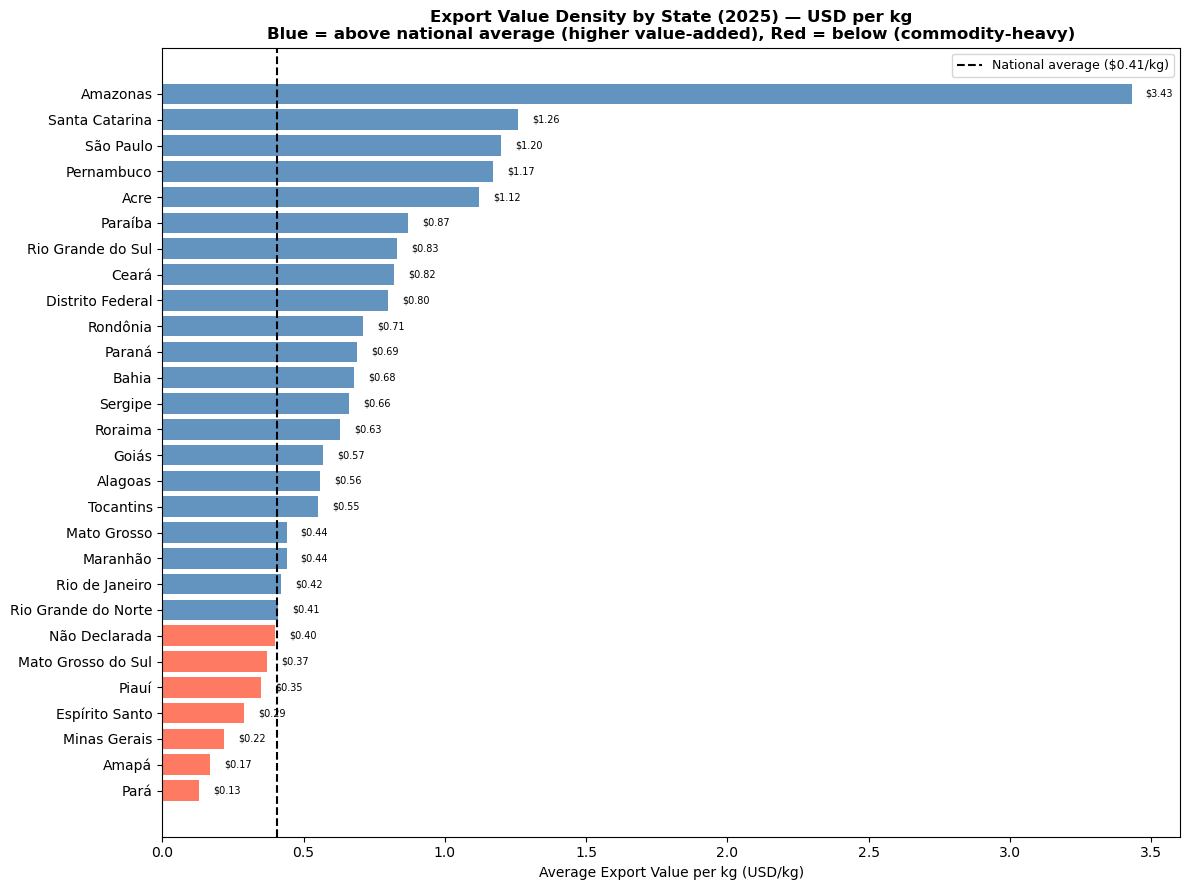


Export value density by state (2025)
National average: $0.41/kg
              state  avg_usd_per_kg
           Amazonas            3.43
     Santa Catarina            1.26
          São Paulo            1.20
         Pernambuco            1.17
               Acre            1.12
            Paraíba            0.87
  Rio Grande do Sul            0.83
              Ceará            0.82
   Distrito Federal            0.80
           Rondônia            0.71
             Paraná            0.69
              Bahia            0.68
            Sergipe            0.66
            Roraima            0.63
              Goiás            0.57
            Alagoas            0.56
          Tocantins            0.55
           Maranhão            0.44
        Mato Grosso            0.44
     Rio de Janeiro            0.42
Rio Grande do Norte            0.41
      Não Declarada            0.40
 Mato Grosso do Sul            0.37
              Piauí            0.35
     Espírito Santo            0.29

In [13]:
## Export value density — USD per kg by state
## High ratio = high value-added exports (industrial/processed goods)
## Low ratio  = low value per kg (bulk commodity exports)
## Uses df_shipsize from 2b.5 — must run 2b.5 first

national_avg_usd_per_kg = df_shipsize['exports_usd'].sum() / df_shipsize['total_kg'].sum()

df_ratio_plot = df_shipsize.sort_values('avg_usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_avg_usd_per_kg else 'tomato'
          for x in df_ratio_plot['avg_usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_ratio_plot['state'], df_ratio_plot['avg_usd_per_kg'],
        color=colors, alpha=0.85)
ax.axvline(x=national_avg_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_avg_usd_per_kg:.2f}/kg)')

for i, (_, row) in enumerate(df_ratio_plot.iterrows()):
    ax.text(row['avg_usd_per_kg'] + 0.05, i,
            f'${row["avg_usd_per_kg"]:.2f}',
            va='center', fontsize=7)

ax.set_title(f'Export Value Density by State ({MAX_YEAR}) — USD per kg\n'
             f'Blue = above national average (higher value-added), '
             f'Red = below (commodity-heavy)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Average Export Value per kg (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2b6_usd_per_kg_ratio.png', dpi=150)
plt.show()

print(f'\nExport value density by state ({MAX_YEAR})')
print(f'National average: ${national_avg_usd_per_kg:.2f}/kg')
print(df_shipsize[['state', 'avg_usd_per_kg']]
      .sort_values('avg_usd_per_kg', ascending=False)
      .to_string(index=False))

## 2b.6 — Logistics Profile Summary: Bulk vs High-Frequency Exporters
Combining shipment frequency, average shipment size and unit price to classify each state's logistics profile. States with large average shipments and low unit price are bulk commodity exporters. States with small average shipments and high unit price are high-frequency value-added exporters.

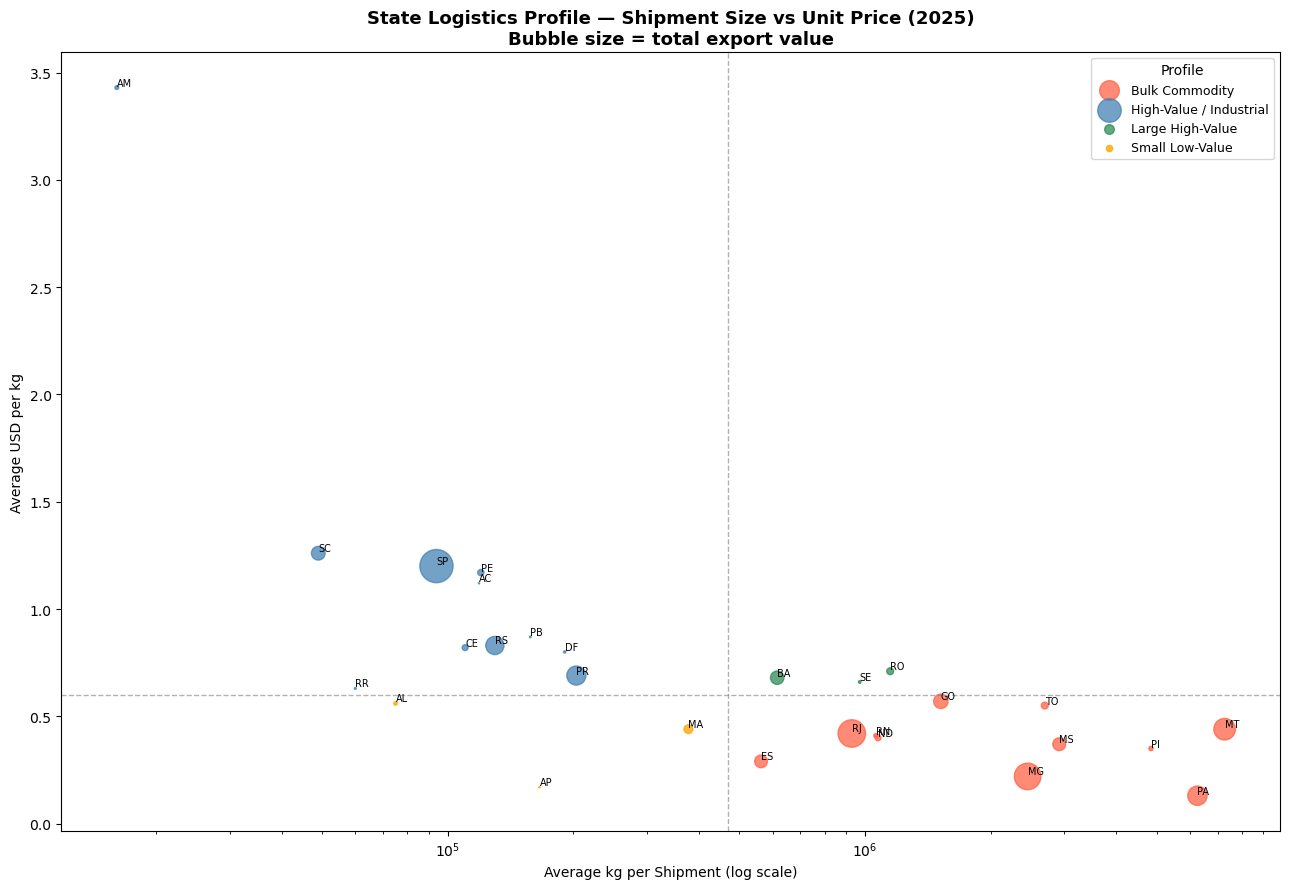


State logistics profile classification (2025)
Median avg kg/shipment: 470,131 | Median avg USD/kg: $0.60
              state               region                 profile  exports_usd_bn  avg_kg_per_shipment  avg_usd_per_kg    hhi
          Tocantins         REGIAO NORTE          Bulk Commodity            3.05            2696422.0            0.55 0.3418
     Rio de Janeiro       REGIAO SUDESTE          Bulk Commodity           48.98             929460.0            0.42 0.6985
       Minas Gerais       REGIAO SUDESTE          Bulk Commodity           45.83            2453172.0            0.22 0.1585
     Espírito Santo       REGIAO SUDESTE          Bulk Commodity           10.51             563167.0            0.29 0.1620
               Pará         REGIAO NORTE          Bulk Commodity           24.34            6262519.0            0.13 0.4365
Rio Grande do Norte      REGIAO NORDESTE          Bulk Commodity            1.13            1061155.0            0.41 0.3462
      Não Declarada

In [8]:
## Combine frequency and size metrics
df_logistics = df_shipsize[[
    'uf', 'state', 'exports_usd_bn', 'shipment_count',
    'avg_kg_per_shipment', 'avg_usd_per_shipment', 'avg_usd_per_kg'
]].copy()
df_logistics = df_logistics.merge(df_state[['uf', 'region']], on='uf', how='left')
df_logistics = df_logistics.merge(df_hhi_prod[['uf', 'hhi']], on='uf', how='left')

## Classify profile based on median thresholds
med_kg  = df_logistics['avg_kg_per_shipment'].median()
med_usd = df_logistics['avg_usd_per_kg'].median()

def classify_profile(row):
    high_kg  = row['avg_kg_per_shipment'] > med_kg
    high_usd = row['avg_usd_per_kg'] > med_usd
    if high_kg and not high_usd:
        return 'Bulk Commodity'
    elif not high_kg and high_usd:
        return 'High-Value / Industrial'
    elif high_kg and high_usd:
        return 'Large High-Value'
    else:
        return 'Small Low-Value'

df_logistics['profile'] = df_logistics.apply(classify_profile, axis=1)

## Scatter plot: avg kg per shipment vs avg USD per kg
profile_colors = {
    'Bulk Commodity'       : 'tomato',
    'High-Value / Industrial': 'steelblue',
    'Large High-Value'     : 'seagreen',
    'Small Low-Value'      : 'orange'
}

fig, ax = plt.subplots(figsize=(13, 9))
for profile, group in df_logistics.groupby('profile'):
    ax.scatter(
        group['avg_kg_per_shipment'],
        group['avg_usd_per_kg'],
        label=profile,
        color=profile_colors.get(profile, 'gray'),
        s=group['exports_usd_bn'] * 8,
        alpha=0.75
    )
    for _, row in group.iterrows():
        ax.annotate(row['uf'], (row['avg_kg_per_shipment'], row['avg_usd_per_kg']),
                    fontsize=7, ha='left', va='bottom')

ax.axvline(x=med_kg,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(y=med_usd, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Average kg per Shipment (log scale)')
ax.set_ylabel('Average USD per kg')
ax.set_xscale('log')
ax.set_title(f'State Logistics Profile — Shipment Size vs Unit Price ({MAX_YEAR})\nBubble size = total export value',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, title='Profile')
plt.tight_layout()
plt.savefig('output_2b6_logistics_scatter.png', dpi=150)
plt.show()

print(f"\nState logistics profile classification ({MAX_YEAR})")
print(f"Median avg kg/shipment: {med_kg:,.0f} | Median avg USD/kg: ${med_usd:.2f}")
print(df_logistics[['state', 'region', 'profile', 'exports_usd_bn',
                     'avg_kg_per_shipment', 'avg_usd_per_kg', 'hhi']]
      .sort_values('profile')
      .to_string(index=False))

## 2b.7 — Key Findings

### Structure
1. **RCA findings** — which states show the strongest comparative advantages and in which sectors; are there any surprising RCA > 1 cases
2. **Specialisation vs diversification** — which states are most specialised (high ESI/HHI) and which mirror the national mix; does specialisation correlate with commodity dependence
3. **Logistics profile** — how many states fall into each quadrant; which states are bulk commodity exporters vs high-frequency industrial exporters
4. **Shipment frequency patterns** — which states have the highest transaction volumes and what that implies about their export base
5. **Limitations** — note that shipment count is a proxy (row count), not an official shipment register; QT_ESTAT varies by product unit
6. **What comes next** — Step 3 municipality-level hotspots